<a href="https://colab.research.google.com/github/yassmin1/Graphs_for_HED/blob/main/A_Beginner_Simple_Friendly_Guide_to_Graph_Data_Structures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install these first if needed:
!pip install networkx matplotlib pandas scikit-learn
# Import graph library
import networkx as nx
# Import plotting library
import matplotlib.pyplot as plt
# Import tools for creating pairs
from itertools import combinations
# Import pandas for table handling
import pandas as pd
# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


People: 12
Friendships: 18


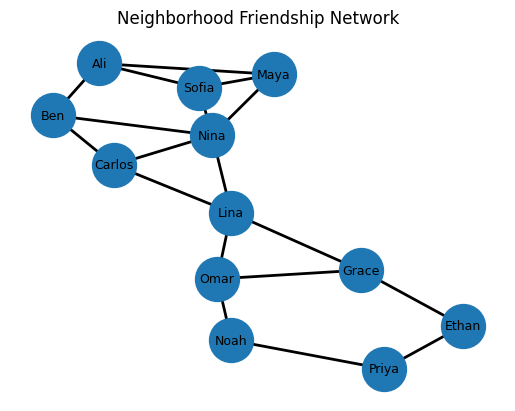

In [2]:

# Create a friendship graph
G = nx.Graph()
# Define friendships
friendships = [
    ("Maya", "Ali"),
    ("Maya", "Sofia"),
    ("Ali", "Sofia"),
    ("Ali", "Ben"),
    ("Sofia", "Nina"),
    ("Ben", "Carlos"),
    ("Carlos", "Nina"),
    ("Nina", "Lina"),
    ("Lina", "Omar"),
    ("Omar", "Grace"),
    ("Grace", "Ethan"),
    ("Ethan", "Priya"),
    ("Priya", "Noah"),
    ("Noah", "Omar"),
    ("Lina", "Grace"),
    ("Maya", "Nina"),
    ("Ben", "Nina"),
    ("Carlos", "Lina")
]
# Add friendships to the graph
G.add_edges_from(friendships)
# Print basic graph information
print("People:", G.number_of_nodes())
print("Friendships:", G.number_of_edges())
# Draw the graph
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=1000)
nx.draw_networkx_edges(G, pos, width=2)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Neighborhood Friendship Network")
plt.axis("off")
plt.show()


In [3]:
# Calculate degree
print("\nDegree:")
for person, degree in G.degree():
    print(person, degree)
# Calculate shortest path
print("\nShortest path from Maya to Ethan:")
print(nx.shortest_path(G, source="Maya", target="Ethan"))
# Calculate clustering
print("\nClustering:")
for person, score in nx.clustering(G).items():
    print(person, round(score, 2))
# Create all possible pairs of people
people = list(G.nodes())
all_pairs = list(combinations(people, 2))
# Create rows for link prediction
rows = []
for person1, person2 in all_pairs:

    # Label is 1 if they are already friends, otherwise 0
    are_friends = 1 if G.has_edge(person1, person2) else 0

    # Count mutual friends
    mutual_friends = len(list(nx.common_neighbors(G, person1, person2)))

    # Calculate Jaccard score
    jaccard_score = list(nx.jaccard_coefficient(G, [(person1, person2)]))[0][2]

    # Calculate preferential attachment score
    pref_score = list(nx.preferential_attachment(G, [(person1, person2)]))[0][2]

    # Save this pair as one row
    rows.append({
        "person1": person1,
        "person2": person2,
        "mutual_friends": mutual_friends,
        "jaccard_score": jaccard_score,
        "preferential_attachment": pref_score,
        "are_friends": are_friends
    })
# Convert rows to table
df = pd.DataFrame(rows)
print("\nLink prediction table:")
print(df.head())



Degree:
Maya 3
Ali 3
Sofia 3
Ben 3
Nina 5
Carlos 3
Lina 4
Omar 3
Grace 3
Ethan 2
Priya 2
Noah 2

Shortest path from Maya to Ethan:
['Maya', 'Nina', 'Lina', 'Grace', 'Ethan']

Clustering:
Maya 0.67
Ali 0.33
Sofia 0.67
Ben 0.33
Nina 0.3
Carlos 0.67
Lina 0.33
Omar 0.33
Grace 0.33
Ethan 0
Priya 0
Noah 0

Link prediction table:
  person1 person2  mutual_friends  jaccard_score  preferential_attachment  \
0    Maya     Ali               1       0.200000                        9   
1    Maya   Sofia               2       0.500000                        9   
2    Maya     Ben               2       0.500000                        9   
3    Maya    Nina               1       0.142857                       15   
4    Maya  Carlos               1       0.200000                        9   

   are_friends  
0            1  
1            1  
2            0  
3            1  
4            0  


In [4]:

# Choose model features
X = df[["mutual_friends", "jaccard_score", "preferential_attachment"]]
# Choose prediction target
y = df["are_friends"]
# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)
# Test the model
predictions = model.predict(X_test)
print("\nModel accuracy:", round(accuracy_score(y_test, predictions), 2))
# Score pairs that are not currently friends
non_friends = df[df["are_friends"] == 0].copy()
# Predict probability of future friendship
non_friends["friendship_score"] = model.predict_proba(
    non_friends[["mutual_friends", "jaccard_score", "preferential_attachment"]]
)[:, 1]
# Show top recommendations
recommendations = non_friends.sort_values(
    "friendship_score",
    ascending=False
)
print("\nTop possible friendship recommendations:")
print(recommendations[[
    "person1",
    "person2",
    "mutual_friends",
    "jaccard_score",
    "preferential_attachment",
    "friendship_score"
]].head(10))


Model accuracy: 0.8

Top possible friendship recommendations:
   person1 person2  mutual_friends  jaccard_score  preferential_attachment  \
40    Nina    Omar               1       0.142857                       15   
41    Nina   Grace               1       0.142857                       15   
13     Ali    Nina               3       0.600000                       15   
15     Ali    Lina               0       0.000000                       12   
5     Maya    Lina               1       0.166667                       12   
24   Sofia    Lina               1       0.166667                       12   
32     Ben    Lina               2       0.400000                       12   
43    Nina   Priya               0       0.000000                       10   
44    Nina    Noah               0       0.000000                       10   
42    Nina   Ethan               0       0.000000                       10   

    friendship_score  
40          0.472232  
41          0.472232  
13       

# Using Facebook dataset


In [5]:
# Import pandas for reading the edge list.
import pandas as pd

# URL for the SNAP Facebook combined edge list.
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"

# Read the compressed text file directly from the web.
# The file has two columns: source user and target user.
edges_df = pd.read_csv(
    url,
    sep=" ",
    header=None,
    names=["source_id", "target_id"]
)

# Show the first few friendship connections.
edges_df.head()

,source_id,target_id
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


Create a Nodes Table
The edge file gives us friendships, We can create the node table by collecting every unique user ID that appears in the edge list.

In [8]:
# Get all unique user IDs from both columns.
all_users = pd.concat([
    edges_df["source_id"],
    edges_df["target_id"]
]).drop_duplicates()

# Create a node table.
users_df = pd.DataFrame({
    "user_id": all_users
})

# Add a simple display name.
# Since the data is anonymized, we will call them User 0, User 1, etc.
users_df["user_name"] = "User " + users_df["user_id"].astype(str)

# Sort users by ID.
users_df = users_df.sort_values("user_id").reset_index(drop=True)

# Show the first few users.
users_df.head()


,user_id,user_name
0,0,User 0
1,1,User 1
2,2,User 2
3,3,User 3
4,4,User 4


In [9]:
# Add a unique edge ID.
edges_df = edges_df.reset_index().rename(columns={"index": "edge_id"})

# Add a simple weight.
# This dataset does not include friendship strength,
# so we set every friendship weight to 1.
edges_df["weight"] = 1

# Show the first few edges.
edges_df.head()

,edge_id,edge_id,source_id,target_id,weight
0,0,0,0,1,1
1,1,1,0,2,1
2,2,2,0,3,1
3,3,3,0,4,1
4,4,4,0,5,1


### Building the Facebook Network Graph

Now, let's create a NetworkX graph from the `edges_df` DataFrame, which contains the Facebook friendship connections. We'll use the `source_id` and `target_id` columns to define the edges.

In [10]:
# Create a NetworkX graph from the edges_df DataFrame.
# The 'source_id' and 'target_id' columns define the nodes and their connections.
G_fb = nx.from_pandas_edgelist(edges_df, source="source_id", target="target_id")

print(f"Number of nodes in Facebook graph: {G_fb.number_of_nodes()}")
print(f"Number of edges in Facebook graph: {G_fb.number_of_edges()}")

Number of nodes in Facebook graph: 4039
Number of edges in Facebook graph: 88234


### Graph Visualization (Considerations for Large Graphs)

The Facebook dataset is significantly larger than the example graph (4039 nodes and 88234 edges). Directly visualizing such a large graph can be computationally intensive and result in an unreadable plot with overlapping nodes and edges. For this reason, we will not attempt to draw the entire graph here. If visualization is needed, it's often better to sample a subgraph or use specialized visualization tools designed for large networks.

### Network Analysis: Degree, Shortest Path, and Clustering

For large graphs, calculating metrics for all nodes can also be time-consuming. We'll demonstrate these concepts by showing statistics for a few sample nodes rather than the entire graph.

First, let's look at the degree of a few nodes. The degree represents the number of direct connections a user has.

In [11]:
# Get the degree of all nodes
degree_sequence = sorted([d for n, d in G_fb.degree()], reverse=True)

print("Top 10 nodes by degree:")
# Convert to a DataFrame for easier sorting and display
degree_df = pd.DataFrame(G_fb.degree(), columns=['user_id', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False).reset_index(drop=True)
display(degree_df.head(10))

# Display the degree for a few specific users (e.g., User 0, User 1, User 2)
print("\nDegrees for specific users:")
for user_id in [0, 1, 2, 100, 500]:
    if G_fb.has_node(user_id):
        print(f"User {user_id}: Degree = {G_fb.degree(user_id)}")
    else:
        print(f"User {user_id}: Not found in graph")

Top 10 nodes by degree:


,user_id,degree
0,107,1045
1,1684,792
2,1912,755
3,3437,547
4,0,347
5,2543,294
6,2347,291
7,1888,254
8,1800,245
9,1663,235



Degrees for specific users:
User 0: Degree = 347
User 1: Degree = 17
User 2: Degree = 10
User 100: Degree = 9
User 500: Degree = 83


#### Shortest Path

The shortest path between two nodes is the minimum number of edges needed to go from one node to another. For large graphs, calculating all-pairs shortest paths is very expensive. We'll find the shortest path between a couple of example users.

In [12]:
print("\nShortest path between User 0 and User 50:")
try:
    path_0_50 = nx.shortest_path(G_fb, source=0, target=50)
    print(f"Path: {path_0_50}")
    print(f"Length: {len(path_0_50) - 1}")
except nx.NetworkXNoPath:
    print("No path found between User 0 and User 50.")

print("\nShortest path between User 100 and User 200:")
try:
    path_100_200 = nx.shortest_path(G_fb, source=100, target=200)
    print(f"Path: {path_100_200}")
    print(f"Length: {len(path_100_200) - 1}")
except nx.NetworkXNoPath:
    print("No path found between User 100 and User 200.")


Shortest path between User 0 and User 50:
Path: [0, 50]
Length: 1

Shortest path between User 100 and User 200:
Path: [100, 0, 200]
Length: 2


#### Clustering Coefficient

The clustering coefficient measures the degree to which nodes in a graph tend to cluster together. In social networks, a high clustering coefficient for a node means its friends are also friends with each other. We'll compute and display the clustering coefficient for a few sample nodes.

In [13]:
print("\nClustering coefficients for specific users:")
# Calculate clustering for a small sample of nodes due to potential computation time
sample_nodes = [0, 1, 2, 100, 500, 1000]
for node in sample_nodes:
    if G_fb.has_node(node):
        clustering_score = nx.clustering(G_fb, node)
        print(f"User {node}: Clustering = {clustering_score:.2f}")
    else:
        print(f"User {node}: Not found in graph")


Clustering coefficients for specific users:
User 0: Clustering = 0.04
User 1: Clustering = 0.42
User 2: Clustering = 0.89
User 100: Clustering = 0.61
User 500: Clustering = 0.37
User 1000: Clustering = 0.53


### Link Prediction: Identifying Potential Friendships

Link prediction is the task of predicting the existence of a link between two nodes in a graph. For social networks, this means identifying potential future friendships. We'll follow a similar approach to the small example graph, but it's crucial to acknowledge the scale of the Facebook dataset.

**Important Note on Scale:** The Facebook graph has 4039 nodes. The number of possible pairs of nodes is N*(N-1)/2. For this graph, that's approximately 8 million potential pairs. Calculating features like common neighbors, Jaccard coefficient, and preferential attachment for all these pairs, and then training a model, can be computationally very expensive and memory-intensive. The following code will attempt to run on the full dataset, but if it takes too long or runs out of memory, consider reducing the scope (e.g., by sampling a subgraph or a subset of non-existent edges).

In [18]:
# Identify all possible pairs of users.
# This can be very computationally intensive for large graphs.

all_nodes = list(G_fb.nodes())
all_possible_pairs = list(combinations(all_nodes, 2))

print(f"Total possible pairs of users: {len(all_possible_pairs)}")

rows_fb = []

for user1, user2 in all_possible_pairs:
    # Label is 1 if they are already friends, otherwise 0
    are_friends_fb = 1 if G_fb.has_edge(user1, user2) else 0

    # Count mutual friends
    mutual_friends_fb = len(list(nx.common_neighbors(G_fb, user1, user2)))

    # Calculate Jaccard score
    # Using try-except for Jaccard, as the denominator can be zero if nodes have no neighbors at all.
    try:
        jaccard_score_fb = list(nx.jaccard_coefficient(G_fb, [(user1, user2)]))[0][2]
    except ZeroDivisionError:
        jaccard_score_fb = 0.0

    # Calculate preferential attachment score
    pref_score_fb = list(nx.preferential_attachment(G_fb, [(user1, user2)]))[0][2]

    # Save this pair as one row
    rows_fb.append({
        "user1": user1,
        "user2": user2,
        "mutual_friends": mutual_friends_fb,
        "jaccard_score": jaccard_score_fb,
        "preferential_attachment": pref_score_fb,
        "are_friends": are_friends_fb
    })

# Convert rows to table
df_fb = pd.DataFrame(rows_fb)
print(f"DataFrame for link prediction created with {len(df_fb)} rows.")
print("Link prediction table (first few rows):")
display(df_fb.head())

Total possible pairs of users: 8154741
DataFrame for link prediction created with 8154741 rows.
Link prediction table (first few rows):


,user1,user2,mutual_friends,jaccard_score,preferential_attachment,are_friends
0,0,1,16,0.045977,5899,1
1,0,2,9,0.025862,3470,1
2,0,3,16,0.045977,5899,1
3,0,4,9,0.025862,3470,1
4,0,5,12,0.034483,4511,1


### Training a Link Prediction Model for the Facebook Graph

Now we'll train a Logistic Regression model to predict new friendships based on the features we calculated (mutual friends, Jaccard coefficient, preferential attachment). Similar to the smaller graph, we'll split the data into training and testing sets, train the model, and then evaluate its accuracy.

In [19]:
# Choose model features
X_fb = df_fb[["mutual_friends", "jaccard_score", "preferential_attachment"]]
# Choose prediction target
y_fb = df_fb["are_friends"]

# Split into train and test data
# We use stratify=y_fb to ensure an even distribution of 'are_friends' (1s and 0s) in both sets
X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(
    X_fb,
    y_fb,
    test_size=0.3,
    random_state=42,
    stratify=y_fb
)

print(f"Training data size: {len(X_train_fb)}")
print(f"Testing data size: {len(X_test_fb)}")

# Create and train the model
# Using a solver that handles larger datasets well, like 'liblinear' or 'sag'
model_fb = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model_fb.fit(X_train_fb, y_train_fb)

# Test the model
predictions_fb = model_fb.predict(X_test_fb)
print(f"\nModel accuracy: {accuracy_score(y_test_fb, predictions_fb):.2f}")

Training data size: 5708318
Testing data size: 2446423

Model accuracy: 0.99


### Top Friendship Recommendations for the Facebook Graph

Finally, let's identify the pairs of users who are not currently friends but have the highest probability of becoming friends according to our model. These are our top link prediction recommendations.

In [20]:
# Score pairs that are not currently friends
non_friends_fb = df_fb[df_fb["are_friends"] == 0].copy()

# Predict probability of future friendship
# Using predict_proba to get the likelihood of belonging to class 1 (being friends)
non_friends_fb["friendship_score"] = model_fb.predict_proba(
    non_friends_fb[["mutual_friends", "jaccard_score", "preferential_attachment"]]
)[:, 1]

# Sort recommendations by friendship score in descending order
recommendations_fb = non_friends_fb.sort_values(
    "friendship_score",
    ascending=False
)

print("\nTop possible friendship recommendations for the Facebook graph:")
display(recommendations_fb[[
    "user1",
    "user2",
    "mutual_friends",
    "jaccard_score",
    "preferential_attachment",
    "friendship_score"
]].head(10))


Top possible friendship recommendations for the Facebook graph:


,user1,user2,mutual_friends,jaccard_score,preferential_attachment,friendship_score
7682060,2088,2369,182,0.854460,39006,0.999984
7556000,1917,2233,183,0.799127,42180,0.999968
7831160,2323,2369,171,0.818182,36051,0.999964
7641484,2033,2492,160,0.837696,30794,0.999961
7604204,1979,2244,169,0.816425,35200,0.999960
6404677,2542,2492,167,0.806763,34888,0.999952
7861910,2381,2601,164,0.811881,33440,0.999951
7610742,1985,2607,182,0.767932,43680,0.999950
7580083,1946,2600,166,0.801932,34762,0.999948
7773511,2229,2600,171,0.784404,37674,0.999943


### Link Prediction: Identifying Potential Friendships

Link prediction is the task of predicting the existence of a link between two nodes in a graph. For social networks, this means identifying potential future friendships. We'll follow a similar approach to the small example graph, but it's crucial to acknowledge the scale of the Facebook dataset.

**Important Note on Scale:** The Facebook graph has 4039 nodes. The number of possible pairs of nodes is N*(N-1)/2. For this graph, that's approximately 8 million potential pairs. Calculating features like common neighbors, Jaccard coefficient, and preferential attachment for all these pairs, and then training a model, can be computationally very expensive and memory-intensive. The following code will attempt to run on the full dataset, but if it takes too long or runs out of memory, consider reducing the scope (e.g., by sampling a subgraph or a subset of non-existent edges).

In [14]:
# Identify all possible pairs of users that are not currently friends.
# This can be very computationally intensive for large graphs.

all_nodes = list(G_fb.nodes())
all_possible_pairs = list(combinations(all_nodes, 2))

print(f"Total possible pairs of users: {len(all_possible_pairs)}")

rows_fb = []

for user1, user2 in all_possible_pairs:
    # Label is 1 if they are already friends, otherwise 0
    are_friends_fb = 1 if G_fb.has_edge(user1, user2) else 0

    # Count mutual friends
    # Only calculate if they are not friends, as this is for prediction
    # For existing edges, common_neighbors returns empty if the edge is removed
    # For efficiency, we calculate this for all pairs and let the model learn
    mutual_friends_fb = len(list(nx.common_neighbors(G_fb, user1, user2)))

    # Calculate Jaccard score
    # Using try-except for Jaccard, as it might fail if nodes have no neighbors
    try:
        jaccard_score_fb = list(nx.jaccard_coefficient(G_fb, [(user1, user2)]))[0][2]
    except ZeroDivisionError: # If denominator is zero (no common neighbors and union is zero)
        jaccard_score_fb = 0.0

    # Calculate preferential attachment score
    pref_score_fb = list(nx.preferential_attachment(G_fb, [(user1, user2)]))[0][2]

    # Save this pair as one row
    rows_fb.append({
        "user1": user1,
        "user2": user2,
        "mutual_friends": mutual_friends_fb,
        "jaccard_score": jaccard_score_fb,
        "preferential_attachment": pref_score_fb,
        "are_friends": are_friends_fb
    })

# Convert rows to table
df_fb = pd.DataFrame(rows_fb)
print(f"DataFrame for link prediction created with {len(df_fb)} rows.")
print("Link prediction table (first few rows):")
display(df_fb.head())

Total possible pairs of users: 8154741
DataFrame for link prediction created with 8154741 rows.
Link prediction table (first few rows):


,user1,user2,mutual_friends,jaccard_score,preferential_attachment,are_friends
0,0,1,16,0.045977,5899,1
1,0,2,9,0.025862,3470,1
2,0,3,16,0.045977,5899,1
3,0,4,9,0.025862,3470,1
4,0,5,12,0.034483,4511,1


### Training a Link Prediction Model for the Facebook Graph

Now we'll train a Logistic Regression model to predict new friendships based on the features we calculated (mutual friends, Jaccard coefficient, preferential attachment). Similar to the smaller graph, we'll split the data into training and testing sets, train the model, and then evaluate its accuracy.

In [15]:
# Choose model features
X_fb = df_fb[["mutual_friends", "jaccard_score", "preferential_attachment"]]
# Choose prediction target
y_fb = df_fb["are_friends"]

# Split into train and test data
# We use stratify=y_fb to ensure an even distribution of 'are_friends' (1s and 0s) in both sets
X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(
    X_fb,
    y_fb,
    test_size=0.3,
    random_state=42,
    stratify=y_fb
)

print(f"Training data size: {len(X_train_fb)}")
print(f"Testing data size: {len(X_test_fb)}")

# Create and train the model
# Using a solver that handles larger datasets well, like 'liblinear' or 'sag'
model_fb = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
model_fb.fit(X_train_fb, y_train_fb)

# Test the model
predictions_fb = model_fb.predict(X_test_fb)
print(f"\nModel accuracy: {accuracy_score(y_test_fb, predictions_fb):.2f}")

Training data size: 5708318
Testing data size: 2446423

Model accuracy: 0.99


### Top Friendship Recommendations for the Facebook Graph

Finally, let's identify the pairs of users who are not currently friends but have the highest probability of becoming friends according to our model. These are our top link prediction recommendations.

In [17]:
# Score pairs that are not currently friends
non_friends_fb = df_fb[df_fb["are_friends"] == 0].copy()

# Predict probability of future friendship
# Using predict_proba to get the likelihood of belonging to class 1 (being friends)
non_friends_fb["friendship_score"] = model_fb.predict_proba(
    non_friends_fb[["mutual_friends", "jaccard_score", "preferential_attachment"]]
)[:, 1]

# Sort recommendations by friendship score in descending order
recommendations_fb = non_friends_fb.sort_values(
    "friendship_score",
    ascending=False
)

print("\nTop possible friendship recommendations for the Facebook graph:")
display(recommendations_fb[[
    "user1",
    "user2",
    "mutual_friends",
    "jaccard_score",
    "preferential_attachment",
    "friendship_score"
]].head(10))


Top possible friendship recommendations for the Facebook graph:


,user1,user2,mutual_friends,jaccard_score,preferential_attachment,friendship_score
7682060,2088,2369,182,0.854460,39006,0.999984
7556000,1917,2233,183,0.799127,42180,0.999968
7831160,2323,2369,171,0.818182,36051,0.999964
7641484,2033,2492,160,0.837696,30794,0.999961
7604204,1979,2244,169,0.816425,35200,0.999960
6404677,2542,2492,167,0.806763,34888,0.999952
7861910,2381,2601,164,0.811881,33440,0.999951
7610742,1985,2607,182,0.767932,43680,0.999950
7580083,1946,2600,166,0.801932,34762,0.999948
7773511,2229,2600,171,0.784404,37674,0.999943
